In [128]:
import pandas as pd # pandas
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import seaborn as sbn
from scipy.stats import mannwhitneyu, wilcoxon # mannwhitneyu and wilcoxon
from sklearn.linear_model import Perceptron         # perceptron
from sklearn.neighbors import KNeighborsClassifier  # knn
from sklearn.linear_model import LogisticRegression # logistic regression
from sklearn.model_selection import cross_val_score, StratifiedKFold # cross-validation and kfold
from sklearn.pipeline import Pipeline # pipeline
from sklearn.preprocessing import MinMaxScaler # minmaxscaler

In [129]:
# Importa dataset
dataset = pd.read_csv("https://raw.githubusercontent.com/joaovictorlopezpereira/Heart-Failure-Predictor/refs/heads/main/csvs/heart-treated-filtered.csv")

In [130]:
# Imprime dataset para conferir corretude da importação
display(dataset)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,ST_Slope_Down,ST_Slope_Up,RestingECG_ST
0,40,1,140,289,0,172,0,0,0,0,1,0,0,0,1,0
1,49,0,160,180,0,156,0,1,1,0,0,1,0,0,0,0
2,37,1,130,283,0,98,0,0,0,0,1,0,0,0,1,1
3,48,0,138,214,0,108,1,1,1,1,0,0,0,0,0,0
4,54,1,150,195,0,122,0,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
736,45,1,110,264,0,132,0,1,1,0,0,0,1,0,0,0
737,68,1,144,193,1,141,0,3,1,1,0,0,0,0,0,0
738,57,1,130,131,0,115,1,1,1,1,0,0,0,0,0,0
739,57,0,130,236,0,174,0,0,1,0,1,0,0,0,0,0


In [131]:
# Função que faz o K-fold Cross Validation
def run_validation(model, X, y, scoring_metric, k, n_runs):
    scores = []
    pipe = Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", model)
    ])
    for seed in range(n_runs):
        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)
        cv_score = cross_val_score(pipe, X, y, cv=cv, scoring=scoring_metric)
        scores.append(cv_score.mean())
    return np.array(scores) # Retorna o array de médias do experimento

In [132]:
# Inicializa knn com 5 vizinhos
knn = KNeighborsClassifier(n_neighbors=7)

# Inicializa reglog com 5000 iterações
reglog = LogisticRegression(max_iter=5000)

# Inicializa perceptron
perceptron = Perceptron(max_iter=2000, tol=1e-3)


In [133]:
# Inicializa X e y como "dataset sem a coluna target" e "coluna target"
X = dataset.drop(columns=["HeartDisease"])
y = dataset['HeartDisease']

# Inicializa k e n_runs
k = 10 # Número de folds do kfold
n_runs = 101 # Número de rodadas

In [134]:
# Mede a acurácia dos modelos
knn_accuracy = run_validation(knn, X, y, 'accuracy', k, n_runs)
reglog_accuracy = run_validation(reglog, X, y, 'accuracy', k, n_runs)
perceptron_accuracy = run_validation(perceptron, X, y, 'accuracy', k, n_runs)

In [144]:
# Mede o f1 dos modelos
knn_f1 = run_validation(knn, X, y, 'f1', k, n_runs)
reglog_f1 = run_validation(reglog, X, y, 'f1', k, n_runs)
perceptron_f1 = run_validation(perceptron, X, y, 'f1', k, n_runs)

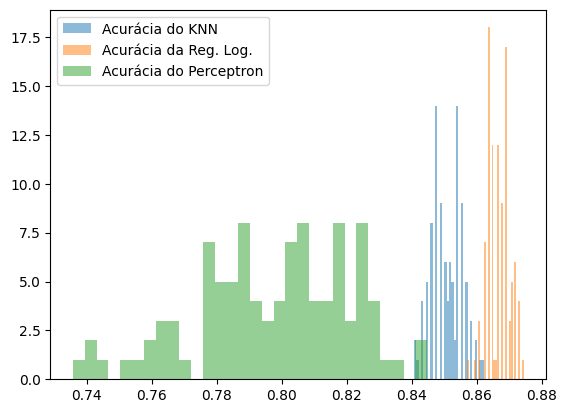

In [136]:
# Plota o histograma das acurácias do teste
plt.hist(knn_accuracy, bins=30, alpha=0.5, label="Acurácia do KNN")
plt.hist(reglog_accuracy, bins=30, alpha=0.5, label="Acurácia da Reg. Log.")
plt.hist(perceptron_accuracy, bins=30, alpha=0.5, label="Acurácia do Perceptron")
plt.legend()
plt.show()


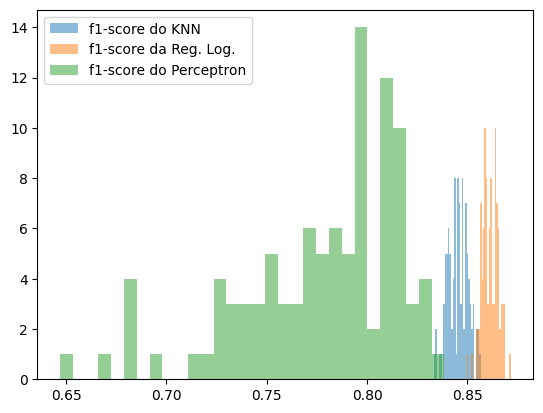

In [145]:
# Plota o histograma dos f1-score do teste
plt.hist(knn_f1, bins=30, alpha=0.5, label="f1-score do KNN")
plt.hist(reglog_f1, bins=30, alpha=0.5, label="f1-score da Reg. Log.")
plt.hist(perceptron_f1, bins=30, alpha=0.5, label="f1-score do Perceptron")
plt.legend()
plt.show()


In [138]:
# Teste de hipótese a respeito da acurácia dos testes
def hypothesis_test(score_1, score_2, name1, name2, alpha):
    # if h0 is true, then score_1 accuracy is <= knn
    _, m_p = mannwhitneyu(score_1, score_2, alternative='greater')

    print(f"p-value: {m_p}")
    print(f"Com {(1 - alpha) * 100}% de confiança,")
    # Rejeita H0
    if (m_p < alpha):
      print(f"Rejeita H0: O {name1}, para esse problema, foi robusto frente ao {name2}")
    # Falha em rejeitar H0
    else:
      print(f"Não rejeita H0: Não há evidências para afirmar que o {name1}, para esse problema, foi robusto frente ao {name2}")

In [139]:
hypothesis_test(perceptron_accuracy, knn_accuracy, "Perceptron", "KNN", 0.01)

p-value: 1.0
Com 99.0% de confiança,
Não rejeita H0: Não há evidências para afirmar que o Perceptron, para esse problema, foi robusto frente ao KNN


In [140]:
hypothesis_test(knn_accuracy, reglog_accuracy, "KNN", "Reg. Log.", 0.01)

p-value: 1.0
Com 99.0% de confiança,
Não rejeita H0: Não há evidências para afirmar que o KNN, para esse problema, foi robusto frente ao Reg. Log.


In [141]:
hypothesis_test(perceptron_accuracy, reglog_accuracy, "Perceptron", "Reg. Log.", 0.01)

p-value: 1.0
Com 99.0% de confiança,
Não rejeita H0: Não há evidências para afirmar que o Perceptron, para esse problema, foi robusto frente ao Reg. Log.


In [142]:
display(perceptron_accuracy.mean())
display(knn_accuracy.mean())
display(reglog_accuracy.mean())

np.float64(0.7972769601284452)

np.float64(0.8509428240121312)

np.float64(0.8667078761930248)

In [146]:
display(perceptron_f1.mean())
display(knn_f1.mean())
display(reglog_f1.mean())

np.float64(0.7772310753344613)

np.float64(0.8454009934582924)

np.float64(0.8613799348587842)